In [1]:
import torch
def cuda_info():
    if torch.cuda.is_available():
        # Target the first GPU
        device_id = 0 

        # Get memory metrics in bytes
        total_mem = torch.cuda.get_device_properties(device_id).total_memory
        reserved_mem = torch.cuda.memory_reserved(device_id)
        allocated_mem = torch.cuda.memory_allocated(device_id)

        # Calculate free space
        free_inside_reserved = reserved_mem - allocated_mem
        total_free_mem = total_mem - allocated_mem

        # Convert bytes to Gigabytes (GB)
        print(f"Total GPU Memory: {total_mem / 1e9:.2f} GB")
        print(f"Allocated Memory: {allocated_mem / 1e9:.2f} GB")
        print(f"Total Available Space: {total_free_mem / 1e9:.2f} GB")
    else:
        print("CUDA is not available on this system.")


In [2]:
import json

def Load_josn(p):
    with open(p, 'r', encoding='utf-8') as f:
        d = json.load(f)
    return d


pdf_urls=Load_josn('data_set\\pdf_urls.json')
question_doc = Load_josn('data_set\\qrels.json')
queries=Load_josn('data_set\\queries.json')
answers=Load_josn('data_set\\answers.json')



In [3]:
import pandas as pd
df = pd.DataFrame.from_dict(question_doc, orient='index')
df.index.name = 'query_id'
df = df.reset_index()  
df.head(2)

,query_id,doc_id,section_id
0,852703f0-8373-43a2-a18a-eb5908ad0779,2410.14077v2,1
1,9199173b-3ed1-4118-88cd-1713fc5fa8a7,2404.00822v2,17


In [4]:
doc_list=df.groupby('doc_id').count().sort_values(by='query_id',ascending=False).head(15).index.tolist()
df=df[df['doc_id'].isin(doc_list)]

### To Download the PDFs use the below block

In [ ]:
import requests, os
from concurrent.futures import ThreadPoolExecutor, as_completed

os.makedirs("pdfs", exist_ok=True)
items ={}
for i ,j in pdf_urls.items():
    if(i in doc_list):
        items[i]=j
    
def download(name_url):
    name, url = name_url
    try:
        fname = os.path.join("pdfs", f"{name}.pdf")
        
        res = requests.get(url, timeout=30)
        res.raise_for_status()
        with open(fname, "wb") as f:
            f.write(res.content)
        return name, True, None
    except Exception as e:
        return name, False, str(e)

pdfs_ = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(download, item) for item in items.items()]
    for future in as_completed(futures):
        name, ok, err = future.result()
        if ok:
            pdfs_.append(name)
        else:
            print(f"failed: {name} -> {err}")

print(f"{len(pdfs_)}/{len(items)} downloaded")

15/15 downloaded


In [5]:
q_df = pd.DataFrame.from_dict(queries, orient='index')  # columns: query, type, source
q_df.index.name = 'query_id'
q_df = q_df.reset_index().rename(columns={'type': 'query_type', 'source': 'query_source', 'query': 'query'})

df = df.merge(q_df, on='query_id', how='left')

In [6]:
answer_df=pd.DataFrame.from_dict(answers,orient="index")
answer_df.index.name='query_id'
df=df.merge(answer_df,on='query_id',how='left')

In [7]:
df=df.rename(columns={0:'answer'})
df.head(2)


,query_id,doc_id,section_id,query,query_type,query_source,answer
0,dc064d11-cd18-4866-8a99-f16b0abec9c6,2401.07294v4,12,How does the MLMM approach affect the analysis...,abstractive,text-image,The MLMM approach affects the analysis of RMSE...
1,7f25612d-9419-4e0a-a89a-9a5a6638e2a6,2411.00816v2,32,Is \(\bar{y}^{\prime}\) considered an unbiased...,extractive,text,"Yes, \(\bar{y}^{\prime}\) is considered an unb..."


In [8]:
df.shape

(150, 7)

---
## Configuration

In [9]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from pydantic import BaseModel
from typing import Literal

# ── Paths ──
PDF_DIR = "pdfs"
TOP_K = 5

# ── Torch compile fix for Windows (Triton not available) ──
os.environ["TORCHDYNAMO_DISABLE"] = "1"

---
## Pydantic model for LLM judge

In [10]:
class RetrievalJudgement(BaseModel):
    relevant_chunks: list[int]            # which chunk numbers are relevant (1-indexed)
    result: Literal["PASS", "FAIL"]       # overall: enough to answer?
    reason: str

---
## Judge prompts

In [11]:
RETRIEVAL_JUDGE_SYSTEM_PROMPT = (
    "You are an evaluator for a Retrieval-Augmented Generation (RAG) system. "
    "Your task is to determine whether the retrieved chunks contain sufficient "
    "and relevant information to answer the given query correctly.\n\n"
    "You will receive:\n"
    "* A QUERY: the question asked by the user.\n"
    "* A GROUND TRUTH ANSWER: the expected answer.\n"
    "* RETRIEVED CHUNKS: the documents/chunks retrieved by the RAG system.\n\n"
    "Evaluate the retrieved chunks as a whole.\n\n"
    "Return:\n"
    "PASS if the retrieved chunks contain enough relevant information to "
    "derive the ground-truth answer.\n"
    "FAIL if:\n"
    "* The retrieved chunks are irrelevant to the query.\n"
    "* The chunks do not contain the information required to answer the query.\n"
    "* Important information required for the ground-truth answer is missing.\n"
    "* The chunks contain information that contradicts the ground-truth answer "
    "and would prevent a correct answer.\n"
    "* The information is too vague or incomplete to reasonably derive the expected answer.\n\n"
    "Important rules:\n"
    "* Judge semantic relevance, not just keyword overlap.\n"
    "* Do not use external knowledge.\n"
    "* Do not assume information that is not present in the retrieved chunks.\n"
    "* The ground-truth answer is the reference for determining whether the "
    "retrieved information is sufficient.\n"
    "* The retrieved chunks do not need to contain the exact wording of the "
    "ground-truth answer.\n"
    "* Paraphrases and semantically equivalent information should be considered valid.\n"
    "* Multiple chunks can collectively provide the required information.\n"
    "* Do not judge the quality of the chunking method itself.\n"
    "* Judge only whether the retrieved content is sufficient for answering the query."
)

RETRIEVAL_JUDGE_USER_TEMPLATE = (
    "Evaluate the following RAG retrieval result.\n\n"
    "QUERY:\n{query}\n\n"
    "GROUND TRUTH ANSWER:\n{ground_truth_answer}\n\n"
    "RETRIEVED CHUNKS:\n{retrieved_chunks}\n\n"
    "Determine whether the retrieved chunks are sufficient to answer the "
    "query and derive the ground-truth answer.\n\n"
    "Also identify which chunk numbers (1-indexed) contain information "
    "relevant to answering the query. A chunk is relevant if it contributes "
    "ANY part of the ground-truth answer, even partially."
)

---
## Helper functions

In [12]:
from rag_eval.embedders import HuggingFaceEmbedder

embedder = HuggingFaceEmbedder()    
def parse_and_chunk(parser, chunker, pdf_path):
    """Parse a PDF and chunk it. Returns list of chunk dicts."""
    doc = parser.parse(pdf_path)
    chunks = chunker.chunk(doc)
    chunk_data = []
    for c in chunks:
        chunk_data.append({
            "chunk_no": c.chunk_no,
            "text": c.text,
            "page_numbers": c.page_numbers,
            "embedding": embedder.embed_query(c.text),
        })
    return chunk_data


def retrieve_top_k(query_embedding, chunks_df, k=TOP_K):
    """Cosine similarity retrieval. Returns top-k chunk dicts."""
    chunk_embs = np.vstack(chunks_df["embedding"].values)
    query_emb = np.array(query_embedding).reshape(1, -1)
    sims = cosine_similarity(query_emb, chunk_embs)[0]
    top_idx = np.argsort(sims)[-k:][::-1]
    results = []
    for idx in top_idx:
        row = chunks_df.iloc[idx]
        results.append({
            "text": row["text"],
            "page_numbers": row["page_numbers"],
            "similarity": float(sims[idx]),
            "chunk_no": row["chunk_no"],
        })
    return results


def format_chunks_for_judge(retrieved):
    """Format retrieved chunks into a string for the judge prompt."""
    parts = []
    for i, c in enumerate(retrieved, 1):
        pages = c["page_numbers"] if c["page_numbers"] else "?"
        parts.append(f"[Chunk {i}, pages {pages}]\n{c['text']}")
    return "\n\n---\n\n".join(parts)


def run_evaluation_pipeline(parser_name, chunks_df, query_df, judge_llm):
    """Run full retrieval evaluation for one parser pipeline.

    For each query:
      1. Retrieve top-k chunks via cosine similarity
      2. Ask the LLM judge: PASS or FAIL?
      3. Track retrieved pages for hit rate analysis
    """
    results = []

    for idx, row in query_df.iterrows():
        query_text = row["query"]
        gt_answer = row["answer"]
        query_emb = row["query_embedding"]

        # Retrieve
        retrieved = retrieve_top_k(query_emb, chunks_df, k=TOP_K)

        # Collect retrieved pages
        retrieved_pages = set()
        for c in retrieved:
            pn = c["page_numbers"]
            if pn:
                if isinstance(pn, list):
                    retrieved_pages.update(pn)
                else:
                    retrieved_pages.add(pn)

        # Format for judge
        chunks_str = format_chunks_for_judge(retrieved)

        # LLM Judge call
        user_prompt = RETRIEVAL_JUDGE_USER_TEMPLATE.format(
            query=query_text,
            ground_truth_answer=gt_answer,
            retrieved_chunks=chunks_str,
        )

        try:
            verdict = judge_llm.invoke_structured(
                prompt=user_prompt,
                response_model=RetrievalJudgement,
                system_prompt=RETRIEVAL_JUDGE_SYSTEM_PROMPT,
            )
            result_val = verdict.result
            reason_val = verdict.reason
            relevant_chunks = verdict.relevant_chunks
        except Exception as e:
            result_val = "ERROR"
            reason_val = str(e)
            relevant_chunks = []

        results.append({
            "query_id": row["query_id"],
            "query": query_text,
            "gt_answer": gt_answer,
            "result": result_val,
            "reason": reason_val,
            "relevant_chunks": relevant_chunks,          # ← new
            "num_relevant": len(relevant_chunks),        # ← new
            "top_similarity": retrieved[0]["similarity"] if retrieved else 0,
            "retrieved_pages": sorted(retrieved_pages),
            "num_chunks": len(retrieved),
        })

        # Progress indicator
        status = result_val
        print(f"  [{status}] {query_text[:80]}")

    return pd.DataFrame(results)


def compute_metrics(results_df, k=TOP_K):
    valid = results_df[results_df["result"].isin(["PASS", "FAIL"])]
    total = len(valid)

    if total == 0:
        return {"precision@k": 0, "hit_rate": 0,
                "pass": 0, "fail": 0, "total": 0, "errors": len(results_df)}

    precisions = []
    hits = 0

    for _, row in valid.iterrows():
        num_relevant = row["num_relevant"]

        # Precision@k: what fraction of retrieved chunks were relevant?
        # denominator = k (total chunks retrieved)
        precisions.append(num_relevant / k)

        # Hit rate: did at least one relevant chunk land in top-k?
        if num_relevant > 0:
            hits += 1

    passes = int((valid["result"] == "PASS").sum())
    fails = int((valid["result"] == "FAIL").sum())

    return {
        "precision@k": round(np.mean(precisions), 4),   # avg(relevant / k)   
        "hit_rate":    round(hits / total, 4),            # queries with ≥1 relevant chunk
        "pass_rate":   round(passes / total, 4),          # overall PASS rate
        "pass":        passes,
        "fail":        fails,
        "total":       total,
        "errors":      int(len(results_df) - total),
    }

d:\projects\RAG-Chunking-Eval\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6421.60it/s]


In [38]:
cuda_info()

Total GPU Memory: 6.44 GB
Allocated Memory: 0.98 GB
Total Available Space: 5.46 GB


---
## Embed all queries (done once, shared by both pipelines)

In [14]:
df.columns

Index(['query_id', 'doc_id', 'section_id', 'query', 'query_type',
       'query_source', 'answer'],
      dtype='object')

In [15]:
df["query_embedding"] = df["query"].apply(embedder.embed_query)
print(f"Embedded {len(df)} queries")

Embedded 150 queries


---
## Initialize Ollama LLM judge

In [17]:
from rag_eval.llms import OllamaLLM
from rag_eval.llms import GroqLLM
from dotenv import load_dotenv
load_dotenv()

# judge_llm = OllamaLLM(model="gemma3:4b", temperature=0.0)
judge_llm=GroqLLM(model="llama-3.3-70b-versatile",api_key=os.getenv("GROQ_KEY"))

# Quick sanity check
test_result = judge_llm.invoke("Say hello in one word.")
print(f"Judge LLM is alive: {test_result}")

Judge LLM is alive: Hello.


In [18]:
cuda_info()

Total GPU Memory: 6.44 GB
Allocated Memory: 0.10 GB
Total Available Space: 6.34 GB


---
---
# Pipeline 1: PDFPlumber + RecursiveChunker

### 1a. Parse & chunk

In [19]:
PDF_PATHS=[f"{PDF_DIR}/{i}" for i in os.listdir(PDF_DIR)]

In [20]:
from rag_eval.parsers import PDFPlumberParser
from rag_eval.chunkers import RecursiveChunker

pdfplumber_parser = PDFPlumberParser()
recursive_chunker = RecursiveChunker()
pdfplumber_chunks=[]
for i in PDF_PATHS:
    pdfplumber_chunks=pdfplumber_chunks+parse_and_chunk(pdfplumber_parser,recursive_chunker,i)

pdfplumber_chunks_df = pd.DataFrame(pdfplumber_chunks)

print(f"PDFPlumber chunks: {len(pdfplumber_chunks_df)}")
print(f"Sample: {pdfplumber_chunks_df.iloc[0]['text'][:150]}...")

PDFPlumber chunks: 2874
Sample: Leveraging IS and TC: Optimal order execution subject to
reference strategies
Xue Cheng1, Peng Guo1, and Tai-Ho Wang2
1
LMEQF,DepartmentofFinancialMat...


### 1b. Run retrieval evaluation

In [21]:
print(f"Evaluating {len(df.head(10))} queries against PDFPlumber chunks...\n")

pdfplumber_results = run_evaluation_pipeline(
    parser_name="pdfplumber",
    chunks_df=pdfplumber_chunks_df,
    query_df=df.head(10),
    judge_llm=judge_llm,
)

pdfplumber_results[["query", "result", "reason"]].head(5)

Evaluating 10 queries against PDFPlumber chunks...

  [PASS] How does the MLMM approach affect the analysis of Root Mean Squared Error (RMSE)
  [PASS] Is \(\bar{y}^{\prime}\) considered an unbiased estimator?
  [PASS] Does bounded invariance affect how probability shares are assigned when preferen
  [FAIL] How can graph drawing methods be combined to handle larger-scale problems?
  [PASS] Why might complex moments be relevant despite not being commonly used in econome
  [PASS] How are complexified tetrahedrons used in knot theory?
  [FAIL] How does the recursive algorithm ensure that all agents receive their preferred 
  [PASS] How can we conclude that one estimator is better than another based on Proxy MSE
  [PASS] Does the complex volume of a manifold include both hyperbolic volume and Chern-S
  [FAIL] How do implementation shortfall (IS) and target close (TC) orders differ in trad


,query,result,reason
0,How does the MLMM approach affect the analysis...,PASS,The retrieved chunks collectively provide suff...
1,Is \(\bar{y}^{\prime}\) considered an unbiased...,PASS,Chunk 1 contains the information that (ar{y}^...
2,Does bounded invariance affect how probability...,PASS,Chunk 1 explicitly states that bounded invaria...
3,How can graph drawing methods be combined to h...,FAIL,The retrieved chunks do not contain sufficient...
4,Why might complex moments be relevant despite ...,PASS,The retrieved chunks collectively provide the ...


### 1c. Metrics

In [23]:
pdfplumber_metrics = compute_metrics(pdfplumber_results)
print("PDFPlumber + RecursiveChunker:")
for k, v in pdfplumber_metrics.items():
    print(f"  {k}: {v}")

PDFPlumber + RecursiveChunker:
  precision@k: 0.4
  hit_rate: 1.0
  pass_rate: 0.7
  pass: 7
  fail: 3
  total: 10
  errors: 0


---
---
# Pipeline 2: Docling + RecursiveChunker

### 2a. Parse & chunk

In [26]:
from pathlib import Path
import pandas as pd

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)


def get_or_create_chunks(
    parser,
    chunker,
    pdf_path,
    cache_path,
):
    """Load cached chunks if available; otherwise parse, chunk and cache."""

    if cache_path.exists():
        print(f"Loading cached chunks from: {cache_path}")
        return pd.read_pickle(cache_path)

    print(f"No cached chunks found for: {pdf_path}")
    print("Running parser + chunker...")

    chunks = parse_and_chunk(
        parser,
        chunker,
        pdf_path,
    )

    chunks_df = pd.DataFrame(chunks)
    chunks_df["source_pdf"] = Path(pdf_path).name

    chunks_df.to_pickle(cache_path)

    print(f"Saved chunks to: {cache_path}")

    return chunks_df

In [27]:
from rag_eval.parsers import DoclingParser

docling_parser = DoclingParser(use_gpu=True)

docling_chunks = []

for pdf_path in PDF_PATHS:

    pdf_path = Path(pdf_path)

    cache_path = (
        CACHE_DIR
        / f"{pdf_path.stem}_docling_recursive.pkl"
    )

    chunks_df = get_or_create_chunks(
        parser=docling_parser,
        chunker=recursive_chunker,
        pdf_path=str(pdf_path),
        cache_path=cache_path,
    )

    docling_chunks.append(chunks_df)


docling_chunks_df = pd.concat(
    docling_chunks,
    ignore_index=True,
)

print(f"Total Docling chunks: {len(docling_chunks_df)}")
print(f"Documents: {len(PDF_PATHS)}")
print(f"Sample: {docling_chunks_df.iloc[0]['text'][:150]}...")

[INFO] 2026-08-17 13:00:01,377 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-08-17 13:00:01,379 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-08-17 13:00:01,390 [RapidOCR] download_file.py:60: File exists and is valid: D:\projects\RAG-Chunking-Eval\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-08-17 13:00:01,391 [RapidOCR] main.py:50: Using D:\projects\RAG-Chunking-Eval\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-08-17 13:00:01,558 [RapidOCR] base.py:23: Using engine_name: torch


No cached chunks found for: pdfs\2401.03305v2.pdf
Running parser + chunker...


[INFO] 2026-08-17 13:00:01,559 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-08-17 13:00:01,561 [RapidOCR] download_file.py:60: File exists and is valid: D:\projects\RAG-Chunking-Eval\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-08-17 13:00:01,562 [RapidOCR] main.py:50: Using D:\projects\RAG-Chunking-Eval\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-08-17 13:00:01,657 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-08-17 13:00:01,659 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-08-17 13:00:01,687 [RapidOCR] download_file.py:60: File exists and is valid: D:\projects\RAG-Chunking-Eval\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_rec_small.pth
[INFO] 2026-08-17 13:00:01,688 [RapidOCR] main.py:50: Using D:\projects\RAG-Chunking-Eval\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_rec_small.pth
Loading weights: 100%|██████████| 770/770 [

Saved chunks to: cache\2401.03305v2_docling_recursive.pkl
No cached chunks found for: pdfs\2401.06987v2.pdf
Running parser + chunker...
Saved chunks to: cache\2401.06987v2_docling_recursive.pkl
No cached chunks found for: pdfs\2401.07294v4.pdf
Running parser + chunker...
Saved chunks to: cache\2401.07294v4_docling_recursive.pkl
No cached chunks found for: pdfs\2401.07317v2.pdf
Running parser + chunker...
Saved chunks to: cache\2401.07317v2_docling_recursive.pkl
No cached chunks found for: pdfs\2401.11899v3.pdf
Running parser + chunker...


[WARNING] 2026-08-17 13:00:56,240 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!


Saved chunks to: cache\2401.11899v3_docling_recursive.pkl
No cached chunks found for: pdfs\2401.15478v2.pdf
Running parser + chunker...
Saved chunks to: cache\2401.15478v2_docling_recursive.pkl
No cached chunks found for: pdfs\2410.23209v2.pdf
Running parser + chunker...
Saved chunks to: cache\2410.23209v2_docling_recursive.pkl
No cached chunks found for: pdfs\2410.23587v3.pdf
Running parser + chunker...
Saved chunks to: cache\2410.23587v3_docling_recursive.pkl
No cached chunks found for: pdfs\2410.23841v2.pdf
Running parser + chunker...
Saved chunks to: cache\2410.23841v2_docling_recursive.pkl
No cached chunks found for: pdfs\2411.00816v2.pdf
Running parser + chunker...
Saved chunks to: cache\2411.00816v2_docling_recursive.pkl
No cached chunks found for: pdfs\2411.03418v4.pdf
Running parser + chunker...
Saved chunks to: cache\2411.03418v4_docling_recursive.pkl
No cached chunks found for: pdfs\2411.03676v2.pdf
Running parser + chunker...
Saved chunks to: cache\2411.03676v2_docling_recu

[WARNING] 2026-08-17 13:03:05,184 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!


Saved chunks to: cache\2412.20317v3_docling_recursive.pkl
No cached chunks found for: pdfs\2501.00225v2.pdf
Running parser + chunker...


[WARNING] 2026-08-17 13:05:01,511 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!
[WARNING] 2026-08-17 13:05:03,039 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!
[WARNING] 2026-08-17 13:05:22,948 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!


Saved chunks to: cache\2501.00225v2_docling_recursive.pkl
No cached chunks found for: pdfs\2501.01454v2.pdf
Running parser + chunker...
Saved chunks to: cache\2501.01454v2_docling_recursive.pkl
Total Docling chunks: 3320
Documents: 15
Sample: 1
Leveraging IS and TC: Optimal order execution subject to reference strategies
Xue Cheng 1 , Peng Guo 1 , and Tai-Ho Wang 2
LMEQF, Department of Fina...


### 2b. Run retrieval evaluation

In [28]:
print(f"Evaluating {len(df.head(10))} queries against Docling chunks...\n")

docling_results = run_evaluation_pipeline(
    parser_name="docling",
    chunks_df=docling_chunks_df,
    query_df=df.head(10),
    judge_llm=judge_llm,
)

docling_results[["query", "result", "reason"]].head(5)

Evaluating 10 queries against Docling chunks...

  [PASS] How does the MLMM approach affect the analysis of Root Mean Squared Error (RMSE)
  [PASS] Is \(\bar{y}^{\prime}\) considered an unbiased estimator?
  [PASS] Does bounded invariance affect how probability shares are assigned when preferen
  [FAIL] How can graph drawing methods be combined to handle larger-scale problems?
  [PASS] Why might complex moments be relevant despite not being commonly used in econome
  [PASS] How are complexified tetrahedrons used in knot theory?
  [FAIL] How does the recursive algorithm ensure that all agents receive their preferred 
  [PASS] How can we conclude that one estimator is better than another based on Proxy MSE
  [PASS] Does the complex volume of a manifold include both hyperbolic volume and Chern-S
  [PASS] How do implementation shortfall (IS) and target close (TC) orders differ in trad


,query,result,reason
0,How does the MLMM approach affect the analysis...,PASS,The retrieved chunks collectively provide suff...
1,Is \(\bar{y}^{\prime}\) considered an unbiased...,PASS,"The retrieved chunks, specifically Chunk 1 and..."
2,Does bounded invariance affect how probability...,PASS,Chunk 1 explicitly states that bounded invaria...
3,How can graph drawing methods be combined to h...,FAIL,The retrieved chunks do not contain enough rel...
4,Why might complex moments be relevant despite ...,PASS,Chunks 1 and 5 collectively provide informatio...


### 2c. Metrics

In [29]:
docling_metrics = compute_metrics(docling_results)
print("Docling + RecursiveChunker:")
for k, v in docling_metrics.items():
    print(f"  {k}: {v}")

Docling + RecursiveChunker:
  precision@k: 0.42
  hit_rate: 1.0
  pass_rate: 0.8
  pass: 8
  fail: 2
  total: 10
  errors: 0


---
---
# Side-by-side comparison

In [30]:
comparison = pd.DataFrame({
    "PDFPlumber + Recursive": pdfplumber_metrics,
    "Docling + Recursive": docling_metrics,
}).T

comparison.index.name = "Pipeline"
comparison

,precision@k,hit_rate,pass_rate,pass,fail,total,errors
Pipeline,,,,,,,
PDFPlumber + Recursive,0.40,1.0,0.7,7.0,3.0,10.0,0.0
Docling + Recursive,0.42,1.0,0.8,8.0,2.0,10.0,0.0


### Per-query diff: where do they disagree?

In [31]:
merged = pdfplumber_results[["query_id", "query", "result", "reason"]].merge(
    docling_results[["query_id", "result", "reason"]],
    on="query_id",
    suffixes=("_pdfplumber", "_docling"),
)

disagree = merged[merged["result_pdfplumber"] != merged["result_docling"]]
print(f"Disagreements: {len(disagree)} / {len(merged)} queries\n")

# Show the interesting cases where parsers diverge
disagree[["query", "result_pdfplumber", "reason_pdfplumber",
          "result_docling", "reason_docling"]]

Disagreements: 1 / 10 queries



,query,result_pdfplumber,reason_pdfplumber,result_docling,reason_docling
9,How do implementation shortfall (IS) and targe...,FAIL,The retrieved chunks do not contain sufficient...,PASS,The retrieved chunks collectively provide suff...


### Visual comparison

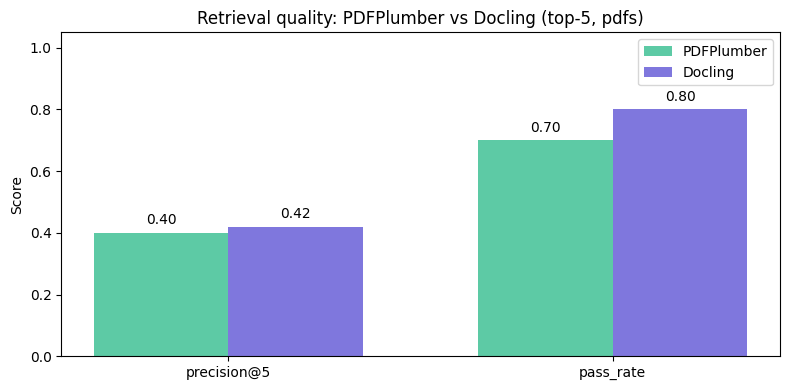

In [37]:
import matplotlib.pyplot as plt

metrics_to_plot = ["precision@k", "pass_rate"]
pdfp_vals = [pdfplumber_metrics[m] for m in metrics_to_plot]
docl_vals = [docling_metrics[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, pdfp_vals, width, label="PDFPlumber", color="#5DCAA5")
bars2 = ax.bar(x + width/2, docl_vals, width, label="Docling", color="#7F77DD")

ax.set_ylabel("Score")
ax.set_title(f"Retrieval quality: PDFPlumber vs Docling (top-{TOP_K}, pdfs)")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("@k", f"@{TOP_K}") for m in metrics_to_plot])
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f"{h:.2f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()